In [3]:
#imports
!pip install scikit-learn pandas numpy matplotlib seaborn scipy mgwr
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap
from scipy import stats as stats


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [ ]:
#exploring the data
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


****what exploration means****
- no null values within the dataset, so no need to drop certain rows
- counts of each series match up, wiuth 20,640 in each column
- Heavy right skew with the average number of rooms and bedrooms, as well as Average occupation as  i.e. positively skewed.
- What happens is, these positively skewed or negatively skewed input features can mess up regression models
- These have to be handled before running standard scaler, as standard scaler still preserves large tails. 
- The concentration in each of the tails can be seen below


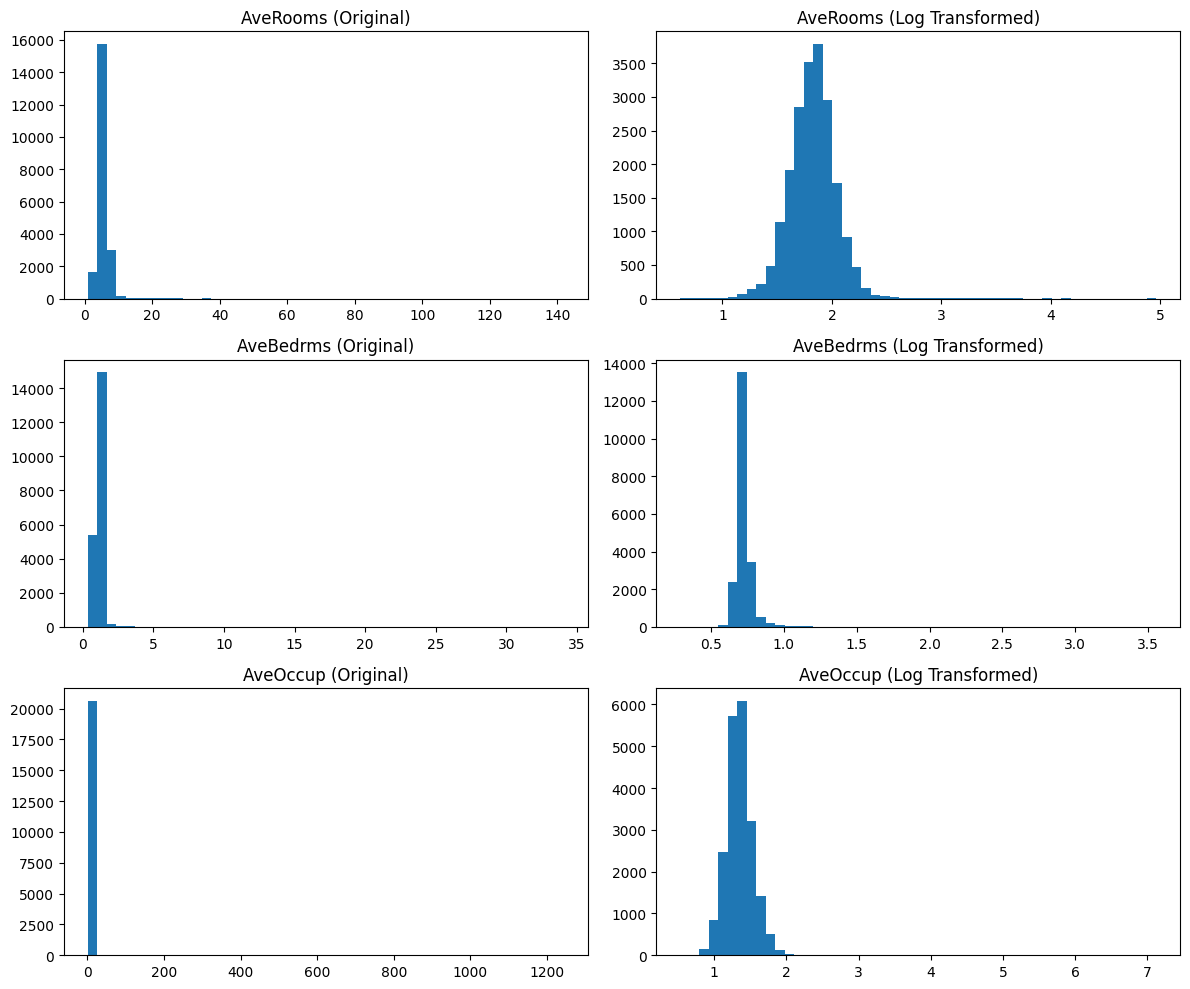

In [6]:
# Apply log transformation to right-skewed columns
df['log_AveRooms'] = np.log1p(df['AveRooms'])
df['log_AveBedrms'] = np.log1p(df['AveBedrms'])
df['log_AveOccup'] = np.log1p(df['AveOccup'])

# Compare distributions before and after
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for idx, col in enumerate(['AveRooms', 'AveBedrms', 'AveOccup']):
    axes[idx, 0].hist(df[col], bins=50)
    axes[idx, 0].set_title(f'{col} (Original)')
    axes[idx, 1].hist(df[f'log_{col}'], bins=50)
    axes[idx, 1].set_title(f'{col} (Log Transformed)')
plt.tight_layout()
plt.show()

****What changed ?****
- If you look at the distributions before and after, you can see after the transform they are more normally distributed
- This puts us in a good position to start normalization using standard scalar
- But before using standard scalar, it assumes normality which we have achieved by removing skewness